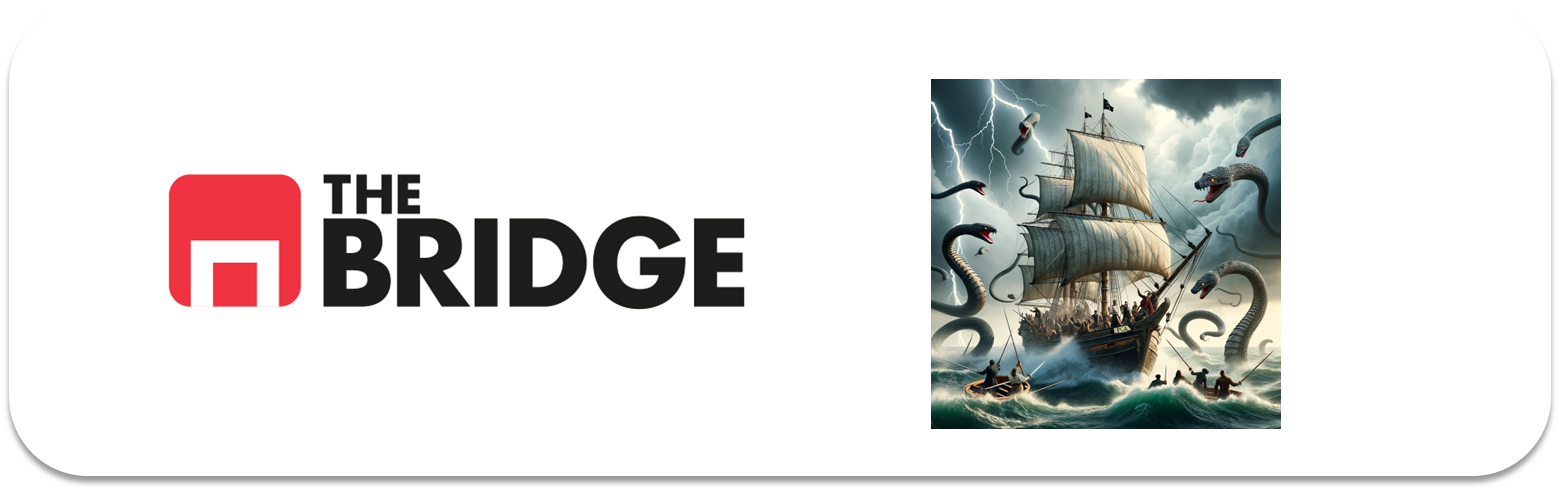

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [43]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel, RFE, SequentialFeatureSelector
from sklearn.metrics import mutual_info_score, balanced_accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import Counter
from catboost import CatBoostClassifier

import bootcampviztools as bt

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


#### 1. Carga y limpieza

In [44]:
df = pd.read_csv("data/credit_npo.csv")
df.shape

(12537, 11)

In [45]:
df.isnull().sum()

SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

Solo un ~6% de las filas tiene algún nulo (en `MonthlyIncome` y `NumberOfDependents`), así que preferimos eliminarlas directamente antes que ponernos a imputar y complicar el análisis.

In [46]:
# nos deshacemos de los nulos, para esta practica no los vamos a imputar
df = df.dropna()
df.shape

(11816, 11)

Convertimos las variables de conteo de impagos y algunas más a categóricas con 3 niveles (0, 1, 2 o más), para que dejen de ser tan dispersas y sean más fáciles de interpretar:

In [47]:
def agrupa_en_niveles(valor):
    if valor == 0:
        return 0
    elif valor == 1:
        return 1
    else:
        return 2

cols_a_categorizar = ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTime60-89DaysPastDueNotWorse",
                       "NumberOfTimes90DaysLate", "NumberRealEstateLoansOrLines", "NumberOfDependents"]

for col in cols_a_categorizar:
    df[col] = df[col].apply(agrupa_en_niveles)

df[cols_a_categorizar].nunique()

NumberOfTime30-59DaysPastDueNotWorse    3
NumberOfTime60-89DaysPastDueNotWorse    3
NumberOfTimes90DaysLate                 3
NumberRealEstateLoansOrLines            3
NumberOfDependents                      3
dtype: int64

Cortamos en 2 porque a partir de ahí las categorías tienen muy pocas muestras, y además hay valores raros como 96 o 98 en algunas columnas que parecen códigos de error más que conteos reales. Agruparlos evita que el modelo les dé un peso que no les corresponde.

#### 2. Train/test split

In [48]:
target = "SeriousDlqin2yrs"
features = [c for c in df.columns if c != target]

X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2,
                                                      random_state=42, stratify=df[target])
X_train.shape, X_test.shape

((9452, 10), (2364, 10))

Usamos un 20% para test y estratificamos por el target, para que la proporción de impagos sea la misma en train y test dado lo desbalanceado que está.

In [49]:
y_train.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.92975
1    0.07025
Name: proportion, dtype: float64

El target está bastante desbalanceado (solo un ~7% son casos de impago), así que usaremos balanced_accuracy como métrica en toda la práctica.

### MiniEDA: Selección de Features

#### 2.1 Análisis visual + correlación / covarianza

In [50]:
num_features = ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio", "MonthlyIncome",
                "NumberOfOpenCreditLinesAndLoans"]
cat_features = ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTime60-89DaysPastDueNotWorse",
                "NumberOfTimes90DaysLate", "NumberRealEstateLoansOrLines", "NumberOfDependents"]

Separamos las features en numéricas continuas y categóricas (las de conteo que acabamos de agrupar) porque cada tipo necesita un test distinto: ANOVA para las numéricas y Mutual Information para las categóricas.

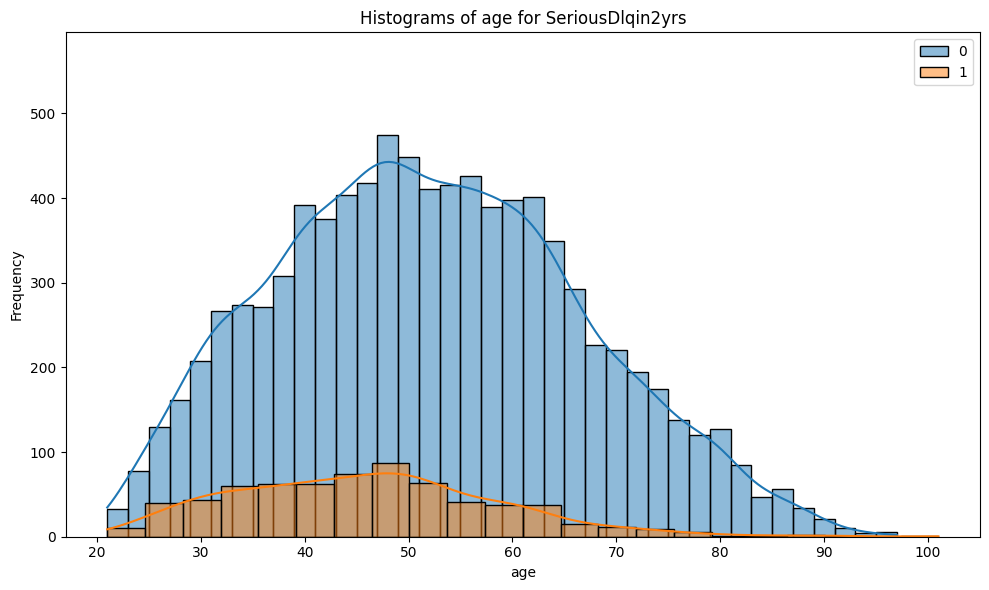

In [51]:
bt.plot_grouped_histograms(X_train.join(y_train), cat_col=target, num_col="age", group_size=2)

In [52]:
corr = X_train.join(y_train).corr()
corr_target = corr[target].drop(target).abs().sort_values(ascending=False)
corr_target

NumberOfTimes90DaysLate                 0.377976
RevolvingUtilizationOfUnsecuredLines    0.277475
NumberOfTime60-89DaysPastDueNotWorse    0.276154
NumberOfTime30-59DaysPastDueNotWorse    0.259018
age                                     0.105251
NumberOfDependents                      0.050502
NumberOfOpenCreditLinesAndLoans         0.033514
NumberRealEstateLoansOrLines            0.026822
MonthlyIncome                           0.025449
DebtRatio                               0.000089
Name: SeriousDlqin2yrs, dtype: float64

Nos quedamos con las features cuya correlación (en valor absoluto) con el target supera un umbral mínimo:

In [53]:
r_minimo = 0.05
feat_visual = corr_target[corr_target >= r_minimo].index.to_list()
feat_visual

['NumberOfTimes90DaysLate',
 'RevolvingUtilizationOfUnsecuredLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'age',
 'NumberOfDependents']

<Axes: >

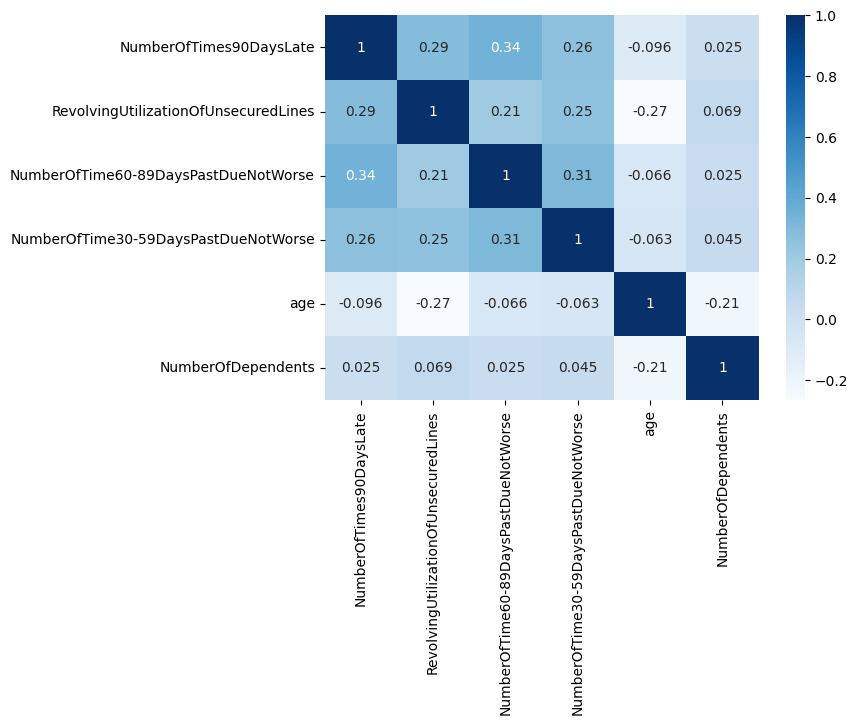

In [54]:
plt.figure(figsize=(7, 5))
sns.heatmap(X_train[feat_visual].corr(), annot=True, cmap="Blues")

Ninguna pareja supera un 0.4 de correlación entre sí, así que no descartamos ninguna por colinealidad. Nos quedamos con esta lista de 6 como selección "visual".

#### 2.2 SelectKBest (ANOVA) para numéricas + Mutual Information para categóricas

In [55]:
selector_anova = SelectKBest(f_classif, k=4)
selector_anova.fit(X_train[num_features], y_train)
feat_anova = list(selector_anova.get_feature_names_out())
feat_anova

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans']

Pedimos 4 porque son justo las numéricas continuas que nos quedan tras convertir el resto a categóricas, así que no tiene mucho sentido pedir más.

In [56]:
mi_scores = {col: mutual_info_score(X_train[col], y_train) for col in cat_features}
pd.Series(mi_scores).sort_values(ascending=False)

NumberOfTimes90DaysLate                 0.035594
NumberOfTime30-59DaysPastDueNotWorse    0.023412
NumberOfTime60-89DaysPastDueNotWorse    0.020504
NumberRealEstateLoansOrLines            0.001393
NumberOfDependents                      0.001263
dtype: float64

In [57]:
feat_mi = pd.Series(mi_scores).sort_values(ascending=False).head(2).index.to_list()

feat_filter = feat_anova + feat_mi
feat_filter

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberOfTime30-59DaysPastDueNotWorse']

De las categóricas nos quedamos solo con las 2 que más información mutua comparten con el target, el resto aporta muy poco (se ve en lo bajo de sus valores).

#### 2.3 Selección con un modelo intermedio (SelectFromModel)

In [58]:
rf_selector = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

selector_modelo = SelectFromModel(rf_selector, max_features=6, threshold=-np.inf)
selector_modelo.fit(X_train, y_train)

feat_modelo = list(selector_modelo.get_feature_names_out())
feat_modelo

['RevolvingUtilizationOfUnsecuredLines',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberOfTime60-89DaysPastDueNotWorse']

Ponemos `threshold=-inf` para que el único criterio de corte sea `max_features=6`, y así nos quedamos siempre con las 6 features más importantes según el Random Forest, en vez de depender de un umbral tipo mediana.

#### 2.4 RFE

In [59]:
rfe = RFE(estimator=RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1),
          n_features_to_select=6, step=1)
rfe.fit(X_train, y_train)

feat_rfe = list(rfe.get_feature_names_out())
feat_rfe

['RevolvingUtilizationOfUnsecuredLines',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberOfTime60-89DaysPastDueNotWorse']

Usamos el mismo Random Forest como estimador base que en el paso anterior, para que la comparación entre métodos sea lo más parecida posible.

#### 2.5 SFS

In [60]:
sfs = SequentialFeatureSelector(RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1),
                                 n_features_to_select=6, cv=3, scoring="balanced_accuracy", n_jobs=-1)
sfs.fit(X_train, y_train)

feat_sfs = list(sfs.get_feature_names_out())
feat_sfs

['RevolvingUtilizationOfUnsecuredLines',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

Aquí usamos `cv=3` en lugar de 5 para que no tarde demasiado: SFS es el método más lento porque entrena un modelo por cada combinación de features que va probando.

#### 2.6 Hard-voting con las 5 listas anteriores

In [61]:
votos = Counter()
for lista in [feat_visual, feat_filter, feat_modelo, feat_rfe, feat_sfs]:
    votos.update(lista)

votos.most_common()

[('NumberOfTimes90DaysLate', 5),
 ('RevolvingUtilizationOfUnsecuredLines', 5),
 ('NumberOfTime30-59DaysPastDueNotWorse', 5),
 ('NumberOfTime60-89DaysPastDueNotWorse', 4),
 ('NumberOfOpenCreditLinesAndLoans', 4),
 ('age', 2),
 ('NumberOfDependents', 2),
 ('DebtRatio', 2),
 ('MonthlyIncome', 1)]

In [62]:
feat_voting = [feature for feature, n_votos in votos.most_common(6)]

listas_features = {
    "visual": feat_visual,
    "filter": feat_filter,
    "modelo": feat_modelo,
    "rfe": feat_rfe,
    "sfs": feat_sfs,
    "voting": feat_voting,
}
listas_features

{'visual': ['NumberOfTimes90DaysLate',
  'RevolvingUtilizationOfUnsecuredLines',
  'NumberOfTime60-89DaysPastDueNotWorse',
  'NumberOfTime30-59DaysPastDueNotWorse',
  'age',
  'NumberOfDependents'],
 'filter': ['RevolvingUtilizationOfUnsecuredLines',
  'age',
  'MonthlyIncome',
  'NumberOfOpenCreditLinesAndLoans',
  'NumberOfTimes90DaysLate',
  'NumberOfTime30-59DaysPastDueNotWorse'],
 'modelo': ['RevolvingUtilizationOfUnsecuredLines',
  'NumberOfTime30-59DaysPastDueNotWorse',
  'DebtRatio',
  'NumberOfOpenCreditLinesAndLoans',
  'NumberOfTimes90DaysLate',
  'NumberOfTime60-89DaysPastDueNotWorse'],
 'rfe': ['RevolvingUtilizationOfUnsecuredLines',
  'NumberOfTime30-59DaysPastDueNotWorse',
  'DebtRatio',
  'NumberOfOpenCreditLinesAndLoans',
  'NumberOfTimes90DaysLate',
  'NumberOfTime60-89DaysPastDueNotWorse'],
 'sfs': ['RevolvingUtilizationOfUnsecuredLines',
  'NumberOfTime30-59DaysPastDueNotWorse',
  'NumberOfOpenCreditLinesAndLoans',
  'NumberOfTimes90DaysLate',
  'NumberOfTime60-89Da

Al hacer el recuento hay empate a partir del quinto puesto entre varias features con 2 votos, así que el sexto feature de la lista de voting depende un poco del orden del diccionario, aunque no cambia mucho el resultado final.

### 3. Comparativa de modelos

Escogemos tres modelos sencillos que representen enfoques distintos y los entrenamos con validación cruzada para cada una de las 6 listas de features: una regresión logística (lineal), un árbol de decisión (no lineal, fácil de interpretar) y un Random Forest (ensemble). Así vemos si algún tipo de modelo se lleva mejor con alguna de las selecciones.

In [71]:
from xgboost import XGBClassifier


modelos = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier( max_depth=5, random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "XGBoost": XGBClassifier(max_depth=5),
    "CatBoost": CatBoostClassifier(depth=5, verbose=False)
}

resultados = []
for nombre_lista, feats in listas_features.items():
    for nombre_modelo, modelo in modelos.items():
        score = cross_val_score(modelo, X_train[feats], y_train, cv=5,
                                 scoring="balanced_accuracy", n_jobs=-1).mean()
        resultados.append({"lista": nombre_lista, "modelo": nombre_modelo, "balanced_accuracy": score})

df_resultados = pd.DataFrame(resultados).sort_values("balanced_accuracy", ascending=False)
df_resultados

,lista,modelo,balanced_accuracy
13,modelo,XGBoost,0.618202
18,rfe,XGBoost,0.618202
28,voting,XGBoost,0.611419
29,voting,CatBoost,0.610642
24,sfs,CatBoost,0.608853
12,modelo,DecisionTree,0.607594
17,rfe,DecisionTree,0.607594
23,sfs,XGBoost,0.606629
14,modelo,CatBoost,0.605008
19,rfe,CatBoost,0.605008


In [72]:
mejor = df_resultados.iloc[0]
mejor

lista                  modelo
modelo                XGBoost
balanced_accuracy    0.618202
Name: 13, dtype: object

El mejor resultado lo da el DecisionTree con la lista obtenida por SelectFromModel/RFE (en este dataset ambas listas coinciden). Nos quedamos con ese modelo y esa selección de features para la siguiente parte.

### 4. Optimización de hiperparámetros

In [74]:
feats_finales = listas_features[mejor["lista"]]
feats_finales

['RevolvingUtilizationOfUnsecuredLines',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberOfTime60-89DaysPastDueNotWorse']

In [86]:
param_grid_xgb={
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [100, 200, 300],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

grid = GridSearchCV(XGBClassifier(random_state=42), param_grid_xgb,
                     scoring="balanced_accuracy", cv=5, n_jobs=-1)
grid.fit(X_train[feats_finales], y_train)

grid.best_params_, grid.best_score_

({'colsample_bytree': 1.0,
  'learning_rate': 0.2,
  'max_depth': 6,
  'n_estimators': 100,
  'subsample': 1.0},
 np.float64(0.6185942880726706))

Probamos varias profundidades y tamaños mínimos de hoja porque un árbol sin restricciones tiende a sobreajustar; controlando `max_depth` y `min_samples_leaf` buscamos que generalice mejor en test.

In [88]:
modelo_final = grid.best_estimator_
y_pred = modelo_final.predict(X_test[feats_finales])

print("Balanced accuracy en test:", balanced_accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

Balanced accuracy en test: 0.5831369152679873
              precision    recall  f1-score   support

           0     0.9410    0.9795    0.9599      2198
           1     0.4079    0.1867    0.2562       166

    accuracy                         0.9239      2364
   macro avg     0.6744    0.5831    0.6080      2364
weighted avg     0.9036    0.9239    0.9105      2364



El modelo mejora algo respecto al baseline de la comparativa, aunque el recall de la clase minoritaria (los impagos) sigue siendo bajo, algo esperable dado el desbalanceo del dataset.

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

Antes de aplicar PCA escalamos las features, porque si no las que tienen rangos más grandes (como `MonthlyIncome`) dominarían las primeras componentes solo por su escala, no por ser más informativas.

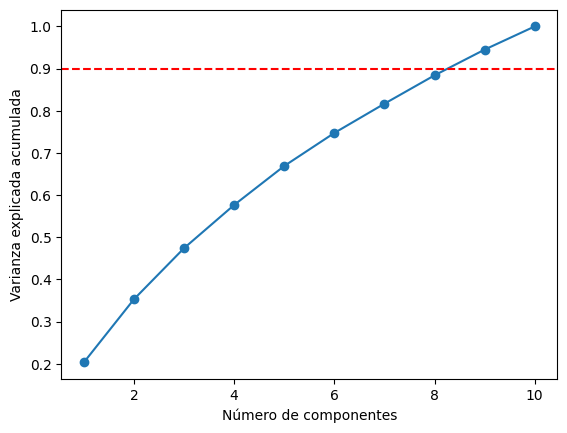

In [83]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

pca = PCA(random_state=42)
pca.fit(X_train_sc)

varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o")
plt.axhline(0.9, color="red", linestyle="--")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.show()

Escogemos el número de componentes que nos permite explicar al menos un 90% de la varianza:

In [84]:
n_componentes = np.argmax(varianza_acumulada >= 0.90) + 1
n_componentes

np.int64(9)

In [85]:
pca_final = PCA(n_components=n_componentes, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_sc)
X_test_pca = pca_final.transform(X_test_sc)

modelo_pca = DecisionTreeClassifier(max_depth=8, random_state=42)
modelo_pca.fit(X_train_pca, y_train)
y_pred_pca = modelo_pca.predict(X_test_pca)

print("Balanced accuracy en test (PCA):", balanced_accuracy_score(y_test, y_pred_pca))

Balanced accuracy en test (PCA): 0.6049036911979127


Con PCA necesitamos 9 de las 10 componentes para llegar al 90% de varianza explicada (apenas hay redundancia entre las features originales), y el resultado en test es parecido al obtenido con la selección de features del apartado anterior, pero perdiendo la interpretabilidad de las variables originales.